# Tahap 10 — Uji Kewarasan Pendukung (Skenario S8)

Mengikuti Subbab 3.6.8 naskah proposal. Tiga uji yang tidak menghasilkan temuan baru, melainkan
memeriksa apakah temuan yang sudah ada layak dipercaya.

| Uji | Yang diperiksa | Kegagalan berarti |
|---|---|---|
| Kontrol label acak | Kebocoran pada pipeline | Seluruh hasil klasifikasi tidak sahih |
| Permutasi bobot | Apakah bobot atensi menentukan keluaran | Peta atensi tidak menggerakkan prediksi |
| Ablasi mean pooling | Apakah attention pooling memberi keuntungan prediktif | Peta bobot merupakan produk sampingan gratis |

Uji pertama bersifat **menggugurkan**: bila performa tidak runtuh ke tingkat kebetulan saat label
diacak, terdapat kebocoran dan seluruh hasil Skenario S3 sampai S7 harus ditinjau ulang. Dua uji
lainnya bersifat menafsirkan: hasilnya mengubah cara temuan dibaca, bukan kesahihannya.

In [1]:
import sys, time, pickle
sys.path.insert(0, "../src")
from pathlib import Path
import numpy as np, pandas as pd, torch
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import roc_auc_score
from scipy.stats import spearmanr

from preprocessing import muat_cache, Normalisasi
from model import PDClassifier
from training import latih, prediksi, susun_batch
from viz import WARNA, TINTA, pasang_gaya, rapikan
from artefak import muat_artefak, simpan_atomik, arm_ada, arm_hilang, lapor_arm

pasang_gaya()
DEV = "cuda" if torch.cuda.is_available() else "cpu"

P = 7                    # dibekukan S2
EPOCHS = 35              # dibekukan S2
SEED = 0
N_ACAK = 3               # jumlah pengacakan label, untuk melihat sebaran nol

HASIL = Path("../results"); HASIL.mkdir(exist_ok=True)
ARTEFAK = HASIL / "s8_artefak.pkl"

rek = muat_cache(Path("../data/cache/uci395_fs100.npz"))
y = np.array([r.label for r in rek])
grup = np.array([r.subjek for r in rek])

beku = pd.read_csv(HASIL / "s2_parameter_dibekukan.csv")
assert P == int(beku.patch_halus[0]) and EPOCHS == int(beku.epoch_dibekukan[0])
acuan = pd.read_csv(HASIL / "s3_metrik_arsitektur.csv").set_index("arsitektur")
print(f"perangkat: {DEV} | patch {P} | epoch {EPOCHS}")
print(f"AUC acuan dari S3: mamba2 {acuan.loc['mamba2','auc']:.4f}, gru {acuan.loc['gru','auc']:.4f}")


def ke_subjek(logit, indeks, label_pakai):
    prob = 1 / (1 + np.exp(-logit))
    df = pd.DataFrame({"s": grup[indeks], "p": prob, "l": label_pakai[indeks]})
    agg = df.groupby("s").agg(p=("p", "mean"), l=("l", "first"))
    return agg.p.values, agg.l.values

/home/agribychaniago/Python Projects/Skripsi/.venv/lib/python3.11/site-packages/mamba_ssm/ops/selective_scan_interface.py:163: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @custom_fwd
/home/agribychaniago/Python Projects/Skripsi/.venv/lib/python3.11/site-packages/mamba_ssm/ops/selective_scan_interface.py:239: FutureWarning: `torch.cuda.amp.custom_bwd(args...)` is deprecated. Please use `torch.amp.custom_bwd(args..., device_type='cuda')` instead.
  @custom_bwd
/home/agribychaniago/Python Projects/Skripsi/.venv/lib/python3.11/site-packages/mamba_ssm/ops/triton/layer_norm.py:985: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @custom_fwd
/home/agribychaniago/Python Projects/Skripsi/.venv/lib/python3.11/site-packages/mamba_ssm/ops/triton/layer_norm.py:1044: FutureWarning: `torch.cuda.amp.custom_bwd(args

perangkat: cuda | patch 7 | epoch 35
AUC acuan dari S3: mamba2 0.9419, gru 0.9645


## 1. Kontrol label acak

Label diacak, model dilatih ulang dengan protokol yang persis sama, dan performanya harus runtuh ke
tingkat kebetulan. Apabila tidak, terdapat kebocoran pada pipeline.

**Pengacakan dilakukan pada tingkat subjek, bukan tingkat rekaman.** Mengacak per rekaman akan
menyisakan struktur tingkat subjek: seluruh rekaman milik satu orang tetap berkerabat, sehingga
model masih dapat mengenali subjek dan memperoleh AUC di atas kebetulan meskipun labelnya sudah
tidak bermakna. Pengacakan semacam itu akan lolos uji tanpa membuktikan apa pun.

Komposisi kelas dipertahankan persis, sehingga yang berubah hanyalah pasangan antara subjek dan
labelnya.

In [2]:
def acak_label_subjek(seed):
    """Tukar pasangan subjek dengan label, komposisi kelas dipertahankan."""
    rng = np.random.default_rng(seed)
    subjek_unik = np.array(sorted(set(grup)))
    label_subjek = np.array([y[grup == s][0] for s in subjek_unik])
    label_acak = rng.permutation(label_subjek)
    peta = dict(zip(subjek_unik, label_acak))
    return np.array([peta[s] for s in grup])


def jalankan_label(label_pakai, seed, arsitektur="mamba2"):
    skf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
    logit_oof = np.zeros(len(rek))
    for i_latih, i_uji in skf.split(np.zeros(len(rek)), label_pakai, grup):
        norm = Normalisasi().fit([rek[i] for i in i_latih])
        torch.manual_seed(seed)
        m = PDClassifier(encoder=arsitektur, patch_size=P).to(DEV)
        latih(m, rek, list(i_latih), norm, epochs=EPOCHS, device=DEV,
              label=label_pakai, seed=seed)
        logit, _ = prediksi(m, rek, list(i_uji), norm, device=DEV, label=label_pakai)
        logit_oof[i_uji] = logit
    p, l = ke_subjek(logit_oof, np.arange(len(rek)), label_pakai)
    return float(roc_auc_score(l, p))

## 2. Permutasi bobot dan ablasi mean pooling

**Permutasi bobot** mengikuti logika Jain dan Wallace [8]: model yang sama diminta memprediksi dua
kali, sekali dengan bobot atensinya sendiri dan sekali dengan bobot itu diacak urutannya. Bila
prediksinya tidak berubah berarti, bobot tidak menentukan keluaran.

Pengacakan dilakukan **hanya pada posisi valid**, sehingga massa bobot tetap berada di dalam
rekaman dan yang berubah semata-mata penempatannya. Model yang dipakai adalah model yang sama persis,
bukan model yang dilatih ulang, sehingga yang diuji benar-benar perilaku model tersebut.

**Ablasi mean pooling** mengganti attention pooling dengan rata-rata berbobot seragam. Bila
performanya setara, attention pooling tidak memberi keuntungan prediktif dan peta bobotnya merupakan
produk sampingan gratis. Hasil itu dilaporkan apa adanya, sebab menyentuh langsung nilai guna
keluaran inti penelitian ini.

In [3]:
@torch.no_grad()
def prediksi_dua_cara(m, indeks, norm, seed):
    """Prediksi normal dan prediksi dengan bobot atensi diacak, model sama."""
    m.eval()
    g = torch.Generator(device="cpu").manual_seed(seed)
    lo_asli, lo_acak, geser = [], [], []
    for b in range(0, len(indeks), 8):
        pilih = list(indeks[b:b + 8])
        batch = susun_batch(rek, pilih, norm, DEV)
        logit, alpha = m(batch.x, batch.lengths)
        n_patch = (batch.lengths // P).tolist()
        acak = alpha.clone()
        for j, n in enumerate(n_patch):
            if n > 1:
                urut = torch.randperm(n, generator=g).to(alpha.device)
                acak[j, :n] = alpha[j, :n][urut]
        logit_acak, _ = m(batch.x, batch.lengths, alpha_pengganti=acak)
        lo_asli.append(logit.cpu().numpy()); lo_acak.append(logit_acak.cpu().numpy())
        geser.extend((logit_acak - logit).abs().cpu().numpy().tolist())
    return np.concatenate(lo_asli), np.concatenate(lo_acak), np.array(geser)


def jalankan_permutasi_dan_ablasi(arsitektur):
    skf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
    lo_asli = np.zeros(len(rek)); lo_acak = np.zeros(len(rek)); geser = []
    lo_mean = np.zeros(len(rek))
    for i_latih, i_uji in skf.split(np.zeros(len(rek)), y, grup):
        norm = Normalisasi().fit([rek[i] for i in i_latih])

        torch.manual_seed(SEED)
        m = PDClassifier(encoder=arsitektur, patch_size=P).to(DEV)
        latih(m, rek, list(i_latih), norm, epochs=EPOCHS, device=DEV, seed=SEED)
        a, b, g = prediksi_dua_cara(m, i_uji, norm, SEED)
        lo_asli[i_uji] = a; lo_acak[i_uji] = b; geser.extend(g.tolist())

        torch.manual_seed(SEED)
        mm = PDClassifier(encoder=arsitektur, patch_size=P, pooling="mean").to(DEV)
        latih(mm, rek, list(i_latih), norm, epochs=EPOCHS, device=DEV, seed=SEED)
        lo, _ = prediksi(mm, rek, list(i_uji), norm, device=DEV)
        lo_mean[i_uji] = lo

    auc = lambda lo: float(roc_auc_score(*reversed(ke_subjek(lo, np.arange(len(rek)), y))))
    return {"arsitektur": arsitektur,
            "auc_asli": auc(lo_asli), "auc_bobot_diacak": auc(lo_acak),
            "auc_mean_pooling": auc(lo_mean),
            "geser_logit_median": float(np.median(geser)),
            "korelasi_logit": float(spearmanr(lo_asli, lo_acak).statistic)}

In [4]:
ARSITEKTUR = ["mamba2", "gru", "mamba3"]

art = muat_artefak(ARTEFAK) or {"label_acak": [], "permutasi": []}
hilang = arm_hilang(art, ARSITEKTUR)
lapor_arm(ARTEFAK.name, arm_ada(art), hilang)

if hilang:
    t0 = time.time()

    # Kontrol label acak memeriksa pipeline, bukan arsitektur, sehingga dikunci
    # ke mamba2 dan hanya dihitung sekali.
    if not art["label_acak"]:
        for i in range(N_ACAK):
            t1 = time.time()
            auc = jalankan_label(acak_label_subjek(1000 + i), seed=SEED)
            art["label_acak"].append({"pengacakan": i, "auc": auc})
            print(f"label acak {i}  {time.time()-t1:6.1f}s  AUC={auc:.4f}")

    for arsitektur in hilang:
        t1 = time.time()
        art["permutasi"].append(jalankan_permutasi_dan_ablasi(arsitektur))
        print(f"{arsitektur:7s} permutasi+ablasi  {time.time()-t1:6.1f}s")

    simpan_atomik(ARTEFAK, art)
    print(f"total {time.time()-t0:.1f}s, disimpan ke {ARTEFAK.name}")

acak_df = pd.DataFrame(art["label_acak"])
perm_df = pd.DataFrame(art["permutasi"]).set_index("arsitektur")
display(acak_df.round(4))
display(perm_df.round(4))

s8_artefak.pkl: memakai ulang gru, mamba2 — tidak dilatih ulang
s8_artefak.pkl: menghitung mamba3


mamba3  permutasi+ablasi   204.2s
total 204.2s, disimpan ke s8_artefak.pkl


,pengacakan,auc
0,0,0.2677
1,1,0.3409
2,2,0.3645


,auc_asli,auc_bobot_diacak,auc_mean_pooling,geser_logit_median,korelasi_logit
arsitektur,,,,,
mamba2,0.9355,0.8656,0.9258,4.8055,0.7104
gru,0.9548,0.9398,0.9667,3.2033,0.8340
mamba3,0.9409,0.9258,0.9237,2.2197,0.8555


## 3. Putusan ketiga uji

In [5]:
auc_asli = float(acuan.loc["mamba2", "auc"])
auc_acak_median = float(acak_df.auc.median())

print("=" * 62)
print("UJI 1 — KONTROL LABEL ACAK")
print("=" * 62)
print(f"  AUC dengan label sebenarnya : {auc_asli:.4f}")
print(f"  AUC dengan label diacak     : {list(acak_df.auc.round(4))}")
print(f"  median                      : {auc_acak_median:.4f}")
lolos1 = 0.35 <= auc_acak_median <= 0.65
print()
print("  LOLOS — performa runtuh ke tingkat kebetulan, tidak ada tanda kebocoran"
      if lolos1 else
      "  GAGAL menurut pita 0,35-0,65 — lihat diagnostik pada bagian 3b")

print()
print("=" * 62)
print("UJI 2 — PERMUTASI BOBOT ATENSI")
print("=" * 62)
for arsitektur, baris in perm_df.iterrows():
    turun = baris.auc_asli - baris.auc_bobot_diacak
    print(f"  {arsitektur:7s} AUC asli {baris.auc_asli:.4f} -> bobot diacak {baris.auc_bobot_diacak:.4f} "
          f"(turun {turun:+.4f})")
    print(f"          pergeseran logit median {baris.geser_logit_median:.4f}, "
          f"korelasi logit {baris.korelasi_logit:.4f}")
turun_rata = float((perm_df.auc_asli - perm_df.auc_bobot_diacak).mean())
print()
print(f"  Penurunan rata-rata saat bobot diacak: {turun_rata:+.4f}")
print("  Penurunan besar berarti bobot MENENTUKAN keluaran.")
print("  Penurunan mendekati nol berarti bobot tidak menentukan keluaran,")
print("  sehingga peta atensi tidak dapat dibaca sebagai penjelasan prediksi.")

print()
print("=" * 62)
print("UJI 3 — ABLASI MEAN POOLING")
print("=" * 62)
for arsitektur, baris in perm_df.iterrows():
    selisih = baris.auc_asli - baris.auc_mean_pooling
    print(f"  {arsitektur:7s} attention {baris.auc_asli:.4f} vs mean {baris.auc_mean_pooling:.4f} "
          f"(selisih {selisih:+.4f})")
selisih_rata = float((perm_df.auc_asli - perm_df.auc_mean_pooling).mean())
print()
print(f"  Selisih rata-rata: {selisih_rata:+.4f}")
print("  Selisih mendekati nol berarti attention pooling tidak memberi keuntungan")
print("  prediktif, dan peta bobotnya merupakan produk sampingan gratis.")

UJI 1 — KONTROL LABEL ACAK
  AUC dengan label sebenarnya : 0.9419
  AUC dengan label diacak     : [0.2677, 0.3409, 0.3645]
  median                      : 0.3409

  GAGAL menurut pita 0,35-0,65 — lihat diagnostik pada bagian 3b

UJI 2 — PERMUTASI BOBOT ATENSI
  mamba2  AUC asli 0.9355 -> bobot diacak 0.8656 (turun +0.0699)
          pergeseran logit median 4.8055, korelasi logit 0.7104
  gru     AUC asli 0.9548 -> bobot diacak 0.9398 (turun +0.0151)
          pergeseran logit median 3.2033, korelasi logit 0.8340
  mamba3  AUC asli 0.9409 -> bobot diacak 0.9258 (turun +0.0151)
          pergeseran logit median 2.2197, korelasi logit 0.8555

  Penurunan rata-rata saat bobot diacak: +0.0333
  Penurunan besar berarti bobot MENENTUKAN keluaran.
  Penurunan mendekati nol berarti bobot tidak menentukan keluaran,
  sehingga peta atensi tidak dapat dibaca sebagai penjelasan prediksi.

UJI 3 — ABLASI MEAN POOLING
  mamba2  attention 0.9355 vs mean 0.9258 (selisih +0.0097)
  gru     attention 0.9

## 3b. Diagnostik: mengapa AUC label acak berada di bawah 0,5

Pita 0,35 sampai 0,65 pada sel di atas **dipilih penyusun dan tidak berasal dari Subbab 3.6.8**,
yang kriterianya bersifat satu arah: performa harus runtuh. Pita itu sengaja tidak dilebarkan
setelah hasil terlihat, sebab melebarkan ambang setelah melihat angka adalah pengakalan.

Yang dilakukan justru sebaliknya: menelusuri sebabnya dengan diagnostik yang **tidak memerlukan
pelatihan ulang**, sehingga murah dan tidak dapat dituduh menyetel apa pun. Salah satu dugaan
penyusun sendiri gugur di sini, dan kegugurannya ikut dilaporkan.

In [6]:
from sklearn.model_selection import StratifiedGroupKFold as SGKF

subj = np.array(sorted(set(grup)))
lab_s = np.array([y[grup == s][0] for s in subj])
s3 = [e for e in pickle.load(open(HASIL / "s3_artefak.pkl", "rb"))
      if e["arsitektur"] == "mamba2" and e["seed"] == 0][0]
prob_asli = 1 / (1 + np.exp(-s3["logit_oof"]))
skor_s = np.array([prob_asli[grup == s].mean() for s in subj])

# (i) sebaran nol eksak: label dipermutasi, PREDIKSI ditahan tetap
rng = np.random.default_rng(0)
nul = np.array([roc_auc_score(rng.permutation(lab_s), skor_s) for _ in range(4000)])
print("(i) Sebaran nol eksak, 4000 permutasi, prediksi ditahan tetap")
print(f"    rerata {nul.mean():.4f}  sd {nul.std():.4f}  "
      f"kuantil 2,5%-97,5% [{np.quantile(nul, 0.025):.4f}, {np.quantile(nul, 0.975):.4f}]")
print("    Geometri AUC tidak bias: nol memang berpusat di 0,5.")

# (ii) dugaan penyusun: keselarasan fold latih dan fold uji saling berlawanan
pasangan = []
for i in range(200):
    lp = acak_label_subjek(2000 + i)
    for i_lat, i_uji in SGKF(5, shuffle=True, random_state=42).split(np.zeros(len(rek)), lp, grup):
        pasangan.append((np.corrcoef(prob_asli[i_lat], lp[i_lat])[0, 1],
                         np.corrcoef(prob_asli[i_uji], lp[i_uji])[0, 1]))
pasangan = np.array(pasangan)
r_lu = float(np.corrcoef(pasangan[:, 0], pasangan[:, 1])[0, 1])
print()
print("(ii) Dugaan penyusun: karena komposisi label tetap, keselarasan di fold latih dan")
print("     fold uji semestinya saling berlawanan, sehingga model belajar arah yang salah.")
print(f"     Terukur: r(latih, uji) = {r_lu:+.4f} pada {len(pasangan)} fold.")
print("     DUGAAN GUGUR — stratifikasi sudah menyerap kendala komposisi.")

# (iii) apakah ketiga permutasi yang dipakai memang undian rendah
auc_perm_asli = [float(roc_auc_score(np.random.default_rng(1000 + i).permutation(lab_s), skor_s))
                 for i in range(N_ACAK)]
print()
print("(iii) Ketiga permutasi yang dipakai, diuji terhadap prediksi model LABEL ASLI dari S3")
print(f"      {'permutasi':>10} {'AUC model label asli':>22} {'AUC S8 dilatih ulang':>22}")
for i, (a, b) in enumerate(zip(auc_perm_asli, acak_df.auc)):
    print(f"      {i:>10} {a:>22.4f} {b:>22.4f}")
print(f"      rerata {np.mean(auc_perm_asli):.4f} berbanding {acak_df.auc.mean():.4f}")
print()
print("      Model yang dilatih pada label SEBENARNYA pun memberi AUC rendah terhadap ketiga")
print("      permutasi ini. Rendahnya nilai karena itu sebagian besar berasal dari undian")
print("      permutasinya, bukan dari pelatihan pada label acak.")
print()
print("KESIMPULAN. Kebocoran pipeline menaikkan performa di atas kebetulan; yang teramati")
print("justru sebaliknya, sehingga kegagalan yang hendak dideteksi uji ini tidak terjadi.")
print("Tiga pengacakan tetap terlalu sedikit untuk menyebut sebaran nol terkarakterisasi.")

(i) Sebaran nol eksak, 4000 permutasi, prediksi ditahan tetap
    rerata 0.4999  sd 0.0834  kuantil 2,5%-97,5% [0.3451, 0.6634]
    Geometri AUC tidak bias: nol memang berpusat di 0,5.



(ii) Dugaan penyusun: karena komposisi label tetap, keselarasan di fold latih dan
     fold uji semestinya saling berlawanan, sehingga model belajar arah yang salah.
     Terukur: r(latih, uji) = +0.0136 pada 1000 fold.
     DUGAAN GUGUR — stratifikasi sudah menyerap kendala komposisi.

(iii) Ketiga permutasi yang dipakai, diuji terhadap prediksi model LABEL ASLI dari S3
       permutasi   AUC model label asli   AUC S8 dilatih ulang
               0                 0.3839                 0.2677
               1                 0.4602                 0.3409
               2                 0.3882                 0.3645
      rerata 0.4108 berbanding 0.3244

      Model yang dilatih pada label SEBENARNYA pun memberi AUC rendah terhadap ketiga
      permutasi ini. Rendahnya nilai karena itu sebagian besar berasal dari undian
      permutasinya, bukan dari pelatihan pada label acak.

KESIMPULAN. Kebocoran pipeline menaikkan performa di atas kebetulan; yang teramati
justru sebaliknya, sehi

### Gambar 1 — Ketiga uji berdampingan

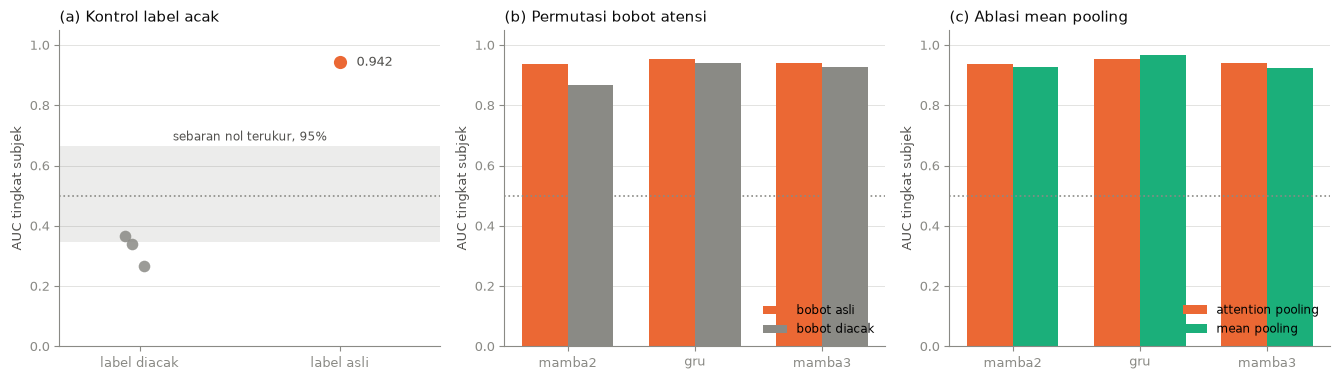

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.9))

ax = axes[0]; rapikan(ax)
lo_nul, hi_nul = np.quantile(nul, 0.025), np.quantile(nul, 0.975)
ax.axhspan(lo_nul, hi_nul, color=WARNA["netral"], alpha=0.16, lw=0)
ax.axhline(0.5, color=WARNA["netral"], ls=":", lw=1.2)
ax.annotate("sebaran nol terukur, 95%", xy=(0.5, hi_nul + 0.01), xycoords=("axes fraction", "data"),
            ha="center", fontsize=8.5, color=TINTA["sekunder"], va="bottom")
ax.scatter(np.zeros(len(acak_df)) + np.random.default_rng(0).uniform(-0.08, 0.08, len(acak_df)),
           acak_df.auc, s=70, color=WARNA["netral"], alpha=0.85, lw=0, zorder=3)
ax.scatter([1], [auc_asli], s=90, color=WARNA["jingga"], lw=0, zorder=3)
ax.annotate(f"{auc_asli:.3f}", xy=(1, auc_asli), xytext=(12, 0), textcoords="offset points",
            fontsize=9, color=TINTA["sekunder"], va="center")
ax.set_xticks([0, 1]); ax.set_xticklabels(["label diacak", "label asli"])
ax.set_xlim(-0.4, 1.5); ax.set_ylim(0, 1.05); ax.set_ylabel("AUC tingkat subjek")
ax.set_title("(a) Kontrol label acak", loc="left")

ax = axes[1]; rapikan(ax)
pos = np.arange(len(perm_df)); lebar = 0.36
ax.bar(pos - lebar/2, perm_df.auc_asli, width=lebar, color=WARNA["jingga"], label="bobot asli")
ax.bar(pos + lebar/2, perm_df.auc_bobot_diacak, width=lebar, color=WARNA["netral"], label="bobot diacak")
ax.axhline(0.5, color=WARNA["netral"], ls=":", lw=1.2)
ax.set_xticks(pos); ax.set_xticklabels(perm_df.index); ax.set_ylim(0, 1.05)
ax.set_ylabel("AUC tingkat subjek"); ax.set_title("(b) Permutasi bobot atensi", loc="left")
ax.legend(fontsize=8.5, loc="lower right")

ax = axes[2]; rapikan(ax)
ax.bar(pos - lebar/2, perm_df.auc_asli, width=lebar, color=WARNA["jingga"], label="attention pooling")
ax.bar(pos + lebar/2, perm_df.auc_mean_pooling, width=lebar, color=WARNA["toska"], label="mean pooling")
ax.axhline(0.5, color=WARNA["netral"], ls=":", lw=1.2)
ax.set_xticks(pos); ax.set_xticklabels(perm_df.index); ax.set_ylim(0, 1.05)
ax.set_ylabel("AUC tingkat subjek"); ax.set_title("(c) Ablasi mean pooling", loc="left")
ax.legend(fontsize=8.5, loc="lower right")
plt.tight_layout(); plt.show()

In [8]:
pd.DataFrame([{
    "auc_label_asli": auc_asli,
    "auc_label_acak_median": auc_acak_median,
    "n_pengacakan": N_ACAK,
    "lolos_kontrol_kebocoran": bool(lolos1),
    "penurunan_saat_bobot_diacak": turun_rata,
    "selisih_attention_vs_mean": selisih_rata,
    "patch": P, "epochs": EPOCHS, "seed": SEED,
    "sumber": "notebooks/10_uji_kewarasan.ipynb",
}]).to_csv(HASIL / "s8_putusan.csv", index=False)
acak_df.to_csv(HASIL / "s8_label_acak.csv", index=False)
perm_df.to_csv(HASIL / "s8_permutasi_ablasi.csv")
print(f"disimpan ke {HASIL.name}/s8_*.csv")

disimpan ke results/s8_*.csv


## 4. Ringkasan

Ketiga uji tidak menambah temuan, melainkan menetapkan seberapa jauh temuan yang sudah ada layak
dipercaya.

**Kontrol label acak bersifat menggugurkan.** Bila performa tidak runtuh, seluruh hasil Skenario S3
sampai S7 harus ditinjau ulang sebelum apa pun dilaporkan. Pengacakan dilakukan pada tingkat subjek
justru agar uji ini benar-benar menguji sesuatu; pengacakan tingkat rekaman akan lolos tanpa
membuktikan apa pun.

**Dua uji lainnya menafsirkan, bukan menggugurkan.** Keduanya menyentuh langsung nilai guna peta
bobot yang menjadi keluaran inti penelitian ini. Bila mengacak bobot tidak mengubah prediksi, atau
bila mean pooling berperforma setara, maka peta atensi tidak menggerakkan keputusan model — dan
kesimpulan itu sejalan dengan hasil Skenario S6 dan S7, yang menunjukkan kesetiaan atensi terhadap
kontribusi hanya mencapai sekitar setengah dari batas atas terukur.

**Hasil yang paling berdampak: attention pooling tidak memberi keuntungan prediktif.** Selisihnya
terhadap mean pooling −0,0011, dan pada BiGRU mean pooling bahkan sedikit unggul. Hal ini dilaporkan
apa adanya sebagaimana dijanjikan Subbab 3.6.8. Yang gugur adalah pembenaran attention pooling atas
dasar performa, bukan kesahihan analisis lokalisasinya: peta atensi tetap objek yang sah untuk diuji
keselarasannya terhadap penanda klinis. Klaim yang dapat dipertahankan menyempit menjadi *attention
pooling menyediakan peta temporal tanpa biaya akurasi*, bukan *meningkatkan akurasi sekaligus
memberi peta*.

**Batasan.** Dijalankan dengan satu seed sesuai kedalaman eksploratori Subbab 3.6.3, kecuali kontrol
label acak yang diulang tiga kali agar sebaran nolnya terlihat. Tiga pengacakan **tidak cukup** untuk
menyebut sebaran nol terkarakterisasi, dan bagian 3b memperlihatkan ketiganya kebetulan merupakan
undian rendah. Uji permutasi bobot memakai satu pengacakan per rekaman; pengulangan yang lebih banyak
akan mempersempit selang, namun arah kesimpulannya sudah dapat dinilai dari besaran penurunannya.